##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]

---

## 0. Iteration setup

**Import libraries**

In [2]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)
import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

**Load & Merge dataset(s)**

In [3]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID

df_ships2 = pd.read_csv("ships_inventory_iter1_leftJoin_iter2_clean.csv")
df_ships2.head(5)

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,Critical,40.0,Ion Drive,Shuttle,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,Pristine,120.0,Solar Sail,Shuttle,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,Critical,40.0,Ion Drive,Shuttle,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,Pristine,40.0,Graviton Beam,Shuttle,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,Critical,40.0,Hyperdrive,Shuttle,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical


In [4]:
df_ships3 = pd.read_csv("ship_performance_logs_iter3.csv")
df_ships3.head(5)

,Ship_ID,Lightyears_Traveled,Registration_Status
0,7316814884,40.610676,Refurbished
1,7316814758,66.153551,Imperial Certified
2,7316814989,10.844388,Refurbished
3,7316743432,29.576094,Refurbished
4,7316356412,122.111671,Refurbished


In [5]:
#left join to keep previous data intact without introducing more unknown data
df_merged2 = df_ships2.merge(df_ships3, left_on='Ship_ID', right_on='Ship_ID', how='left')
df_merged2.head()

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,...,Propulsion_Type,Ship_Class,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity,Lightyears_Traveled,Registration_Status
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,...,Ion Drive,Shuttle,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical,104.554402,Smuggler Logic
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,...,Solar Sail,Shuttle,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine,21.540154,Imperial Certified
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,...,Ion Drive,Shuttle,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical,87.313033,Imperial Certified
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,...,Graviton Beam,Shuttle,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational,144.885019,Imperial Certified
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,...,Hyperdrive,Shuttle,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical,124.394203,Smuggler Logic


---

## 1. Business Understanding

**Situation description**

Nebula Brokerage is moving beyond the simple rule-based and statistical models from earlier iterations because those approaches cannot adequately capture the complexity of the data. The relationships between feature are nonlinear and interdependent. As a result, the previous model are underfit to the total and compete datasat (iter 1 2 3) and fail to generalize well to new data(iter3). A machine learning approach allows the company to better model these complex patterns and improve prediction quality.

**Business objective(s)**

The goal is to build an AI-driven pipeline that predicts both Galactic Credits (price) and Condition. This adds business value by:

- Improving pricing accuracy, leading to better profit margins and competitiveness
- Standardizing condition assessment, reducing subjectivity and human error
- Enabling faster and more scalable decision-making

**Data mining goal(s)**

There are two modeling tasks in this iteration:

- Regression task: Predict Galactic Credits (The price)
- Classification task: Predict Condition (critical, operational, pristine)

**Success criteria**

The new models MUST outpreform the previos iteration 1 and 2 by less MAE, RMSE and a better accuraty > 85% and a better R*2 score.

The model achives acceptable scores on the train and test sets: less he 20% difference in MAE and RMSE

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [6]:
df_merged2.info()
df_merged2.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368314 entries, 0 to 368313
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Unnamed: 0.1                  368314 non-null  int64  
 1   Unnamed: 0                    368314 non-null  int64  
 2   Ship_ID                       368314 non-null  int64  
 3   Galactic_Credits              368314 non-null  int64  
 4   Model_Cycle                   360916 non-null  float64
 5   Ship_Manufacturer             368314 non-null  object 
 6   Sector                        368314 non-null  object 
 7   Model_Cycle_Clean             368314 non-null  float64
 8   Galactic_Credits_Clean        368314 non-null  int64  
 9   Is_Outlier                    368314 non-null  bool   
 10  Hull_Integrity                368314 non-null  object 
 11  Reactor_Power                 338876 non-null  float64
 12  Propulsion_Type               311704 non-nul

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,368314.0,1.841565e+05,1.063232e+05,0.000000e+00,9.207825e+04,1.841565e+05,2.762348e+05,3.683130e+05
Unnamed: 0,368314.0,1.843607e+05,1.064758e+05,0.000000e+00,9.214325e+04,1.843375e+05,2.765768e+05,3.688130e+05
Ship_ID,368314.0,7.311484e+09,4.381194e+06,7.301583e+09,7.308103e+09,7.312604e+09,7.315244e+09,7.317101e+09
Galactic_Credits,368314.0,1.945424e+04,1.554266e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,360916.0,7.511264e+03,9.079721e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Model_Cycle_Clean,368314.0,7.511299e+03,8.991369e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Galactic_Credits_Clean,368314.0,1.930990e+04,1.436495e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.800000e+04
Reactor_Power,338876.0,7.159256e+01,4.464415e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Reactor_Power_Clean,368314.0,7.049083e+01,4.319317e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02
Lightyears_Traveled,361069.0,1.048270e+02,8.894300e+01,0.000000e+00,3.060655e+01,8.547708e+01,1.575455e+02,1.559606e+03


In [7]:
cols = ['Lightyears_Traveled', 'Registration_Status']

missing_count = df_merged2[cols].isnull().sum()

# Percentage of missing values
missing_percentage = (df_merged2[cols].isnull().sum() / len(df_merged2)) * 100

# combine into one table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing (%)': missing_percentage
})

print(missing_summary)

                     Missing Count  Missing (%)
Lightyears_Traveled           7245     1.967072
Registration_Status           7245     1.967072


2 new datacollums have been added: Lightyears_Traveled showing the odometer of the ship in lightyears, and Registration_Status showing the status of the ship according to the imperial registry showing if a ship has a criminal background posibly leading to legal problems for the sale. 

**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.

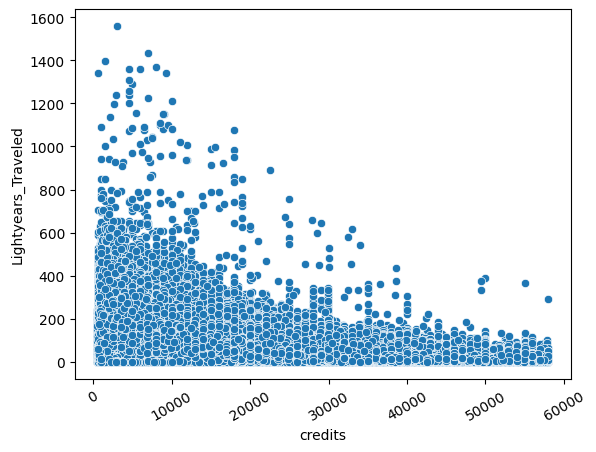

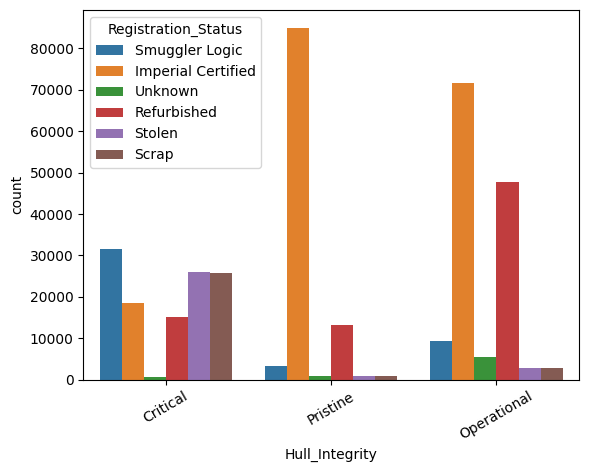

In [8]:
sns.scatterplot(data=df_merged2, x='Galactic_Credits_Clean', y='Lightyears_Traveled')
plt.xticks(rotation=30)
plt.xlabel("credits")
plt.show()
sns.countplot(data=df_merged2, x="Hull_Integrity", hue="Registration_Status")
plt.xticks(rotation=30)
plt.show()


**Data insights and data quality**

* **Insights:** Does high mileage lower the price? Does a 'Stolen' status correlate with critical hull condition?
* **Quality issues:** Document any missing values and other issues

there is a downwards corelation between lightyears traveled and credits, above a surtain point the dencety of data decreases severely, posibly pointing to overpriced vehicles.

critical vehicles are significantly more likely to be involved in criminal activity, while pristene is almost never involved in such businesses.


the number of amount of missing data in the new rows is low, so it won't skew the data too much without creating bias.

---

## 3. Data Preparation

**Cleaning and preprocessing**

*Describe and justify how you resolve your data errors.*

In [9]:
# lightyears get filled with the median, because it is the most likely to be closer to the correct number
df_merged2['Lightyears_Traveled'] = df_merged2['Lightyears_Traveled'].fillna(df_merged2['Lightyears_Traveled'].median())

# if hull integrity is prisine or operational it is safe to asume the vehicle is clean
df_merged2.loc[
    (df_merged2['Registration_Status'].isna()) &
    (df_merged2['Hull_Integrity'].isin(['Pristine', 'Operational'])),
    'Registration_Status'
] = 'Imperial_Certified'

# else it is unsurtain what the vehicle is so it is unknown due to the balance of critical vehicles
df_merged2['Registration_Status'] = df_merged2['Registration_Status'].fillna('Unknown')

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [10]:
#adds new collum that puts Hull_Integrity in a numeric value from critical = 0 to pristine = 2,
#so the higher the vallue, the better the condition
df_merged2['Hull_Integrity_Numerical'] = df_merged2['Hull_Integrity'].map({
    'Critical': 0,
    'Operational': 1,
    'Pristine': 2
})

#adds new collum that puts Registration_Status in a numeric value from Scrap or Unknown = 0 to Imperial Certified = 3,
#so the higher the vallue, the better the condition
df_merged2['Registration_Status_Numerical'] = df_merged2['Registration_Status'].map({
    'Scrap': 0,
    'Unknown': 0,
    'Stolen': 1,
    'Smuggler': 1,
    'Refurbished': 2,
    'Imperial Certified': 3
})
df_merged2.head(10)

,Unnamed: 0.1,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Model_Cycle_Clean,Galactic_Credits_Clean,Is_Outlier,...,Model_Cycle_Bin,Missing,Reactor_Power_Clean,Propulsion_Type_Clean,Possible_Overclocked_reactor,Predicted_Hull_Integrity,Lightyears_Traveled,Registration_Status,Hull_Integrity_Numerical,Registration_Status_Numerical
0,0,0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,7505.0,4950,False,...,"(7503.0, 7507.0]",False,40.0,Ion Drive,False,Critical,104.554402,Smuggler Logic,0,NaN
1,1,1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,7518.0,18999,False,...,"(7517.0, 7519.0]",False,120.0,Solar Sail,False,Pristine,21.540154,Imperial Certified,2,3.0
2,2,2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,7486.0,4000,False,...,"(7399.999, 7503.0]",False,40.0,Ion Drive,False,Critical,87.313033,Imperial Certified,0,3.0
3,3,3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,7511.0,6495,False,...,"(7510.0, 7512.0]",False,40.0,Graviton Beam,False,Operational,144.885019,Imperial Certified,2,3.0
4,4,4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,7499.0,3995,False,...,"(7399.999, 7503.0]",False,40.0,Hyperdrive,False,Critical,124.394203,Smuggler Logic,0,NaN
5,5,5,7313451637,25990,7519.0,Republic Aerospace,Calodan Expanse,7519.0,25990,False,...,"(7517.0, 7519.0]",True,80.0,Ion Drive,False,Pristine,11.419077,Imperial Certified,2,3.0
6,6,6,7316546982,4000,7509.0,General Mining Corp,Mimban Swamp,7509.0,4000,False,...,"(7507.0, 7510.0]",True,60.0,Ion Drive,False,Critical,279.210053,Smuggler Logic,0,NaN
7,7,7,7311754900,7999,7508.0,Hondo Systems,Mon Cala Ocean Worlds,7508.0,7999,False,...,"(7507.0, 7510.0]",True,60.0,Solar Sail,False,Critical,76.050568,Imperial Certified,0,3.0
8,8,8,7313137564,5999,7497.0,Bayerische Motoren Wormhole,Iridonia Belt,7497.0,5999,False,...,"(7399.999, 7503.0]",False,60.0,Ion Drive,False,Critical,210.427682,Unknown,0,0.0
9,9,9,7302916705,58995,7517.0,General Mining Corp,Wroona Spaceport,7517.0,58995,False,...,"(7516.0, 7517.0]",False,80.0,Nuclear Pulse,False,Pristine,85.477075,Imperial_Certified,1,NaN


---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [11]:
# CODE CELL: Train-Test split & train the Linear Regression model

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

In [12]:
# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*


Feature Importance:

                                  feature  importance
128     Predicted_Hull_Integrity_Critical    0.561703
129  Predicted_Hull_Integrity_Operational    0.203703
39    Ship_Manufacturer_Nebula Industries    0.088603
3                        Galactic_Credits    0.066096
4                             Model_Cycle    0.034962
..                                    ...         ...
133       Registration_Status_Refurbished    0.000000
134             Registration_Status_Scrap    0.000000
135    Registration_Status_Smuggler Logic    0.000000
136            Registration_Status_Stolen    0.000000
137           Registration_Status_Unknown    0.000000

[138 rows x 2 columns]


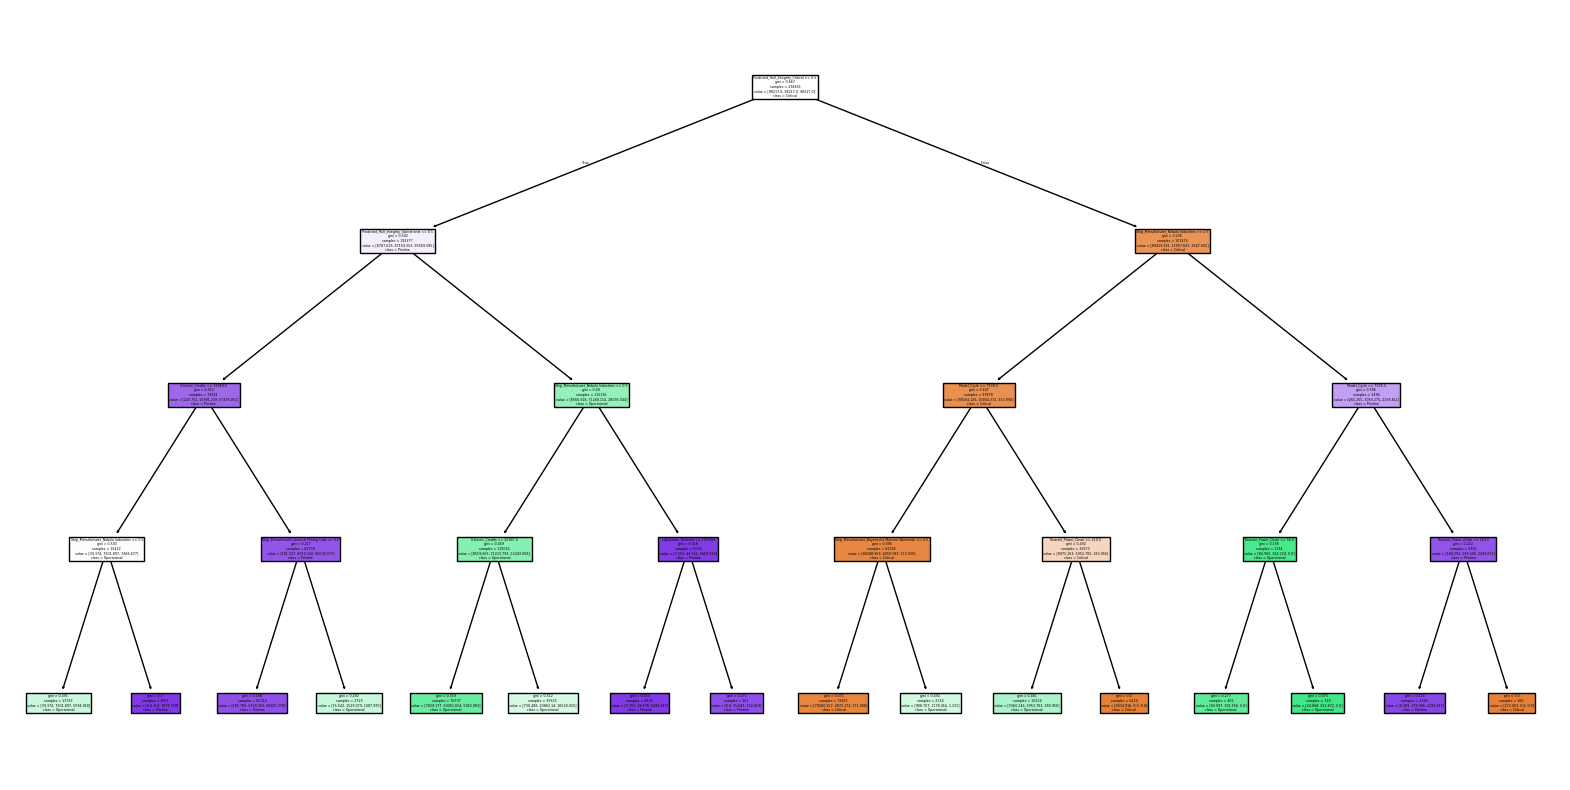

In [38]:
# CODE CELL: Train-Test split & train the Decision Tree model.
# 1. COPY DATA
df = df_merged2.copy()

df = df.drop(columns=[
    "Hull_Integrity_Numerical",
])

# =========================
# 3. TARGET / FEATURES SPLIT (NO LEAKAGE)
# =========================
y = df["Hull_Integrity"]
X = df.drop(columns=["Hull_Integrity"])

# Fill missing values first
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna("Unknown")
    else:
        X[col] = X[col].fillna(X[col].median())

# One-hot encode ALL object columns automatically
X = pd.get_dummies(X)

# =========================
# 6. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y
)

# =========================
# 7. MODEL TRAINING
# =========================
clf = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=80,
    min_samples_split=200,
    class_weight="balanced",
    random_state=67
)

clf.fit(X_train, y_train)

# =========================
# 9. FEATURE IMPORTANCE
# =========================
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": clf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:\n")
print(importance)

# VISUALIZE TREE
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True
)
plt.show()

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

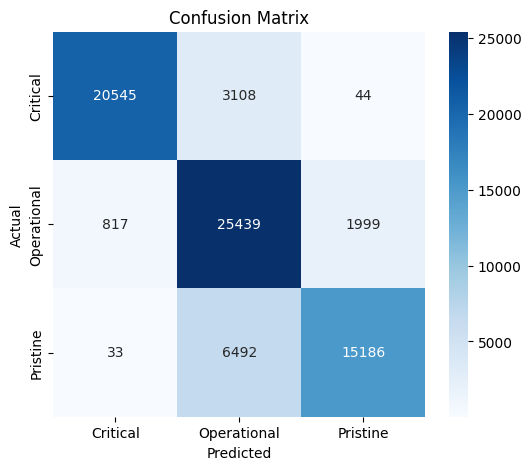

Accuracy: 0.8304033232423333

Classification Report:

              precision    recall  f1-score   support

    Critical       0.96      0.87      0.91     23697
 Operational       0.73      0.90      0.80     28255
    Pristine       0.88      0.70      0.78     21711

    accuracy                           0.83     73663
   macro avg       0.86      0.82      0.83     73663
weighted avg       0.85      0.83      0.83     73663



In [39]:
# CODE CELL: Evaluate your classification model (check out the metrics, include a confusion matrix)
# Predict
y_true = y_test
y_pred = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,5))
labels = np.unique(y_true)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* *Are thr scores of this regression model better than Iteration 1? Why?*

**Key findings and limitations**

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

### Comparison to baseline (manual rules vs decision tree)

The decision tree performs better than the manual rule-based model from Iteration 2. Accuracy improved from 0.80 to 0.84, showing that the machine learning model is more effective overall.

The main reason is that the decision tree learns patterns directly from data instead of using fixed human-made rules. This allows it to capture more complex relationships between features like cycle, credits, and ship type.

Both models perform well at detecting Critical ships, but struggle more with separating Operational and Pristine.

**Key findings and limitations**

The decision tree is more accurate and flexible than manual rules and updates automatically when retrained. However, it can still struggle with overlapping classes and may change slightly depending on the data used.

**Conclusion**

Nebula Brokerage should deploy the decision tree model because it is more accurate and adaptable than manual rules. However, it should still be used carefully, especially for distinguishing between Operational and Pristine ships.


Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

In [40]:
df_merged2.to_csv('Complete_DataSet_iter3.csv')

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | *Make model B* | *I learned that although the model is very good at predicting and deciding what features are good/bad data but I still play a big role in deciding the depth and the encoding of data because if I skrew up in those items than i still get a bad model independed of the other capability's of the code. To sum it up: GiGo = Garbage in is Garbage out* |
| Boaz Vaneveld | *Contribution description* | *Personal lessons learned this iteration* |
| Bart Geijtenbeek | imported csv's, wrote data understanding, wrote data prep | *Personal lessons learned this iteration* |